In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 4)

In [4]:
# ── Load all 4 merged CSVs ──────────────────────────────────────────────────
CASES = {
    'single_case1':  '../data/merged/single_case1_merged.csv',
    'single_case2':  '../data/merged/single_case2_merged.csv',
    'complex_case1': '../data/merged/complex_case1_merged.csv',
    'complex_case2': '../data/merged/complex_case2_merged.csv',
}

dfs = {name: pd.read_csv(path) for name, path in CASES.items()}

# Convert timestamps to datetime for readability
for df in dfs.values():
    df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')

print('Loaded cases:', list(dfs.keys()))

Loaded cases: ['single_case1', 'single_case2', 'complex_case1', 'complex_case2']


In [5]:
# ── Basic shape & dtypes ────────────────────────────────────────────────────
for name, df in dfs.items():
    print(f'\n=== {name} ===')
    print(f'  Rows: {len(df):,}  |  Cols: {df.shape[1]}')
    print(f'  Time range: {df["datetime"].min()}  →  {df["datetime"].max()}')
    duration_h = (df['timestamp'].max() - df['timestamp'].min()) / 3600
    print(f'  Duration : {duration_h:.1f} hours')


=== single_case1 ===
  Rows: 74,223  |  Cols: 11
  Time range: 2024-06-24 18:00:00  →  2024-06-25 03:20:00
  Duration : 9.3 hours

=== single_case2 ===
  Rows: 45,738  |  Cols: 11
  Time range: 2024-06-24 10:00:00  →  2024-06-24 15:59:45
  Duration : 6.0 hours

=== complex_case1 ===
  Rows: 318,445  |  Cols: 11
  Time range: 2024-06-24 05:00:00  →  2024-06-25 15:59:45
  Duration : 35.0 hours

=== complex_case2 ===
  Rows: 94,932  |  Cols: 11
  Time range: 2024-06-19 04:00:00  →  2024-06-19 16:00:00
  Duration : 12.0 hours


In [6]:
# ── Column overview ─────────────────────────────────────────────────────────
print('Columns:', list(dfs['single_case1'].columns))
dfs['single_case1'].dtypes

Columns: ['timestamp', 'cmdb_id', 'new_container_id', 'container_cpu_usage_seconds_total', 'container_cpu_system_seconds_total', 'container_cpu_user_seconds_total', 'container_memory_usage_bytes', 'container_memory_working_set_bytes', 'container_memory_rss', 'container_memory_cache', 'datetime']


timestamp                                      int64
cmdb_id                                       object
new_container_id                              object
container_cpu_usage_seconds_total            float64
container_cpu_system_seconds_total           float64
container_cpu_user_seconds_total             float64
container_memory_usage_bytes                 float64
container_memory_working_set_bytes           float64
container_memory_rss                         float64
container_memory_cache                       float64
datetime                              datetime64[ns]
dtype: object

In [7]:
# ── Missing values check ────────────────────────────────────────────────────
for name, df in dfs.items():
    nulls = df.isnull().sum()
    if nulls.any():
        print(f'{name}: {nulls[nulls > 0].to_dict()}')
    else:
        print(f'{name}: no missing values')

single_case1: no missing values
single_case2: no missing values
complex_case1: no missing values
complex_case2: no missing values


In [8]:
# ── Unique containers (should be 27 per case) ───────────────────────────────
for name, df in dfs.items():
    containers = sorted(df['cmdb_id'].unique())
    print(f'\n{name} — {len(containers)} containers:')
    for c in containers:
        print(f'  {c}')


single_case1 — 27 containers:
  observe.cartservice-0
  observe.cartservice-1
  observe.cartservice-2
  observe.checkoutservice-0
  observe.checkoutservice-1
  observe.checkoutservice-2
  observe.currencyservice-0
  observe.currencyservice-1
  observe.currencyservice-2
  observe.emailservice-0
  observe.emailservice-1
  observe.emailservice-2
  observe.frontend-0
  observe.frontend-1
  observe.frontend-2
  observe.paymentservice-0
  observe.paymentservice-1
  observe.paymentservice-2
  observe.productcatalogservice-0
  observe.productcatalogservice-1
  observe.productcatalogservice-2
  observe.recommendationservice-0
  observe.recommendationservice-1
  observe.recommendationservice-2
  observe.shippingservice-0
  observe.shippingservice-1
  observe.shippingservice-2

single_case2 — 27 containers:
  observe.cartservice-0
  observe.cartservice-1
  observe.cartservice-2
  observe.checkoutservice-0
  observe.checkoutservice-1
  observe.checkoutservice-2
  observe.currencyservice-0
  obser

In [9]:
# ── Sampling frequency (interval between timestamps per container) ──────────
df_sc1 = dfs['single_case1'].copy()
df_sc1_sorted = df_sc1.sort_values(['cmdb_id', 'timestamp'])
sample_container = df_sc1_sorted[df_sc1_sorted['cmdb_id'] == 'observe.frontend-0']
intervals = sample_container['timestamp'].diff().dropna().value_counts()
print('Timestamp intervals (seconds) for observe.frontend-0:')
print(intervals.head(5))

Timestamp intervals (seconds) for observe.frontend-0:
timestamp
15.0    2240
0.0      508
Name: count, dtype: int64


In [10]:
# ── Descriptive statistics — single_case1 as reference ──────────────────────
METRIC_COLS = [
    'container_cpu_usage_seconds_total',
    'container_cpu_system_seconds_total',
    'container_cpu_user_seconds_total',
    'container_memory_usage_bytes',
    'container_memory_working_set_bytes',
    'container_memory_rss',
    'container_memory_cache',
]

dfs['single_case1'][METRIC_COLS].describe().round(2)

,container_cpu_usage_seconds_total,container_cpu_system_seconds_total,container_cpu_user_seconds_total,container_memory_usage_bytes,container_memory_working_set_bytes,container_memory_rss,container_memory_cache
count,74223.00,74223.00,74223.00,7.422300e+04,7.422300e+04,7.422300e+04,74223.00
mean,650.73,148.50,406.06,8.293411e+07,8.207793e+07,6.965964e+07,8513293.27
std,531.66,135.54,379.13,1.521337e+07,1.462112e+07,9.696171e+06,10650843.06
min,114.12,15.92,31.66,5.800755e+07,5.800755e+07,5.313741e+07,548864.00
25%,213.27,46.05,90.16,6.734643e+07,6.710886e+07,6.004736e+07,1290240.00
50%,476.29,84.23,293.96,8.482816e+07,8.422605e+07,6.978765e+07,3051520.00
75%,925.65,218.38,638.29,9.014886e+07,8.939110e+07,7.904461e+07,13819904.00
max,2347.05,628.30,1552.09,1.849344e+08,1.848361e+08,1.788928e+08,41705472.00


In [11]:
# ── Per-service container grouping ──────────────────────────────────────────
# Extract service name from cmdb_id (strip 'observe.' prefix)
df_ref = dfs['single_case1'].copy()
df_ref['service'] = df_ref['cmdb_id'].str.replace('observe.', '', regex=False).str.rsplit('-', n=1).str[0]

service_groups = df_ref.groupby('service')['cmdb_id'].unique()
print('Services and their containers:')
for svc, containers in service_groups.items():
    print(f'  {svc}: {sorted(containers)}')

Services and their containers:
  cartservice: ['observe.cartservice-0', 'observe.cartservice-1', 'observe.cartservice-2']
  checkoutservice: ['observe.checkoutservice-0', 'observe.checkoutservice-1', 'observe.checkoutservice-2']
  currencyservice: ['observe.currencyservice-0', 'observe.currencyservice-1', 'observe.currencyservice-2']
  emailservice: ['observe.emailservice-0', 'observe.emailservice-1', 'observe.emailservice-2']
  frontend: ['observe.frontend-0', 'observe.frontend-1', 'observe.frontend-2']
  paymentservice: ['observe.paymentservice-0', 'observe.paymentservice-1', 'observe.paymentservice-2']
  productcatalogservice: ['observe.productcatalogservice-0', 'observe.productcatalogservice-1', 'observe.productcatalogservice-2']
  recommendationservice: ['observe.recommendationservice-0', 'observe.recommendationservice-1', 'observe.recommendationservice-2']
  shippingservice: ['observe.shippingservice-0', 'observe.shippingservice-1', 'observe.shippingservice-2']


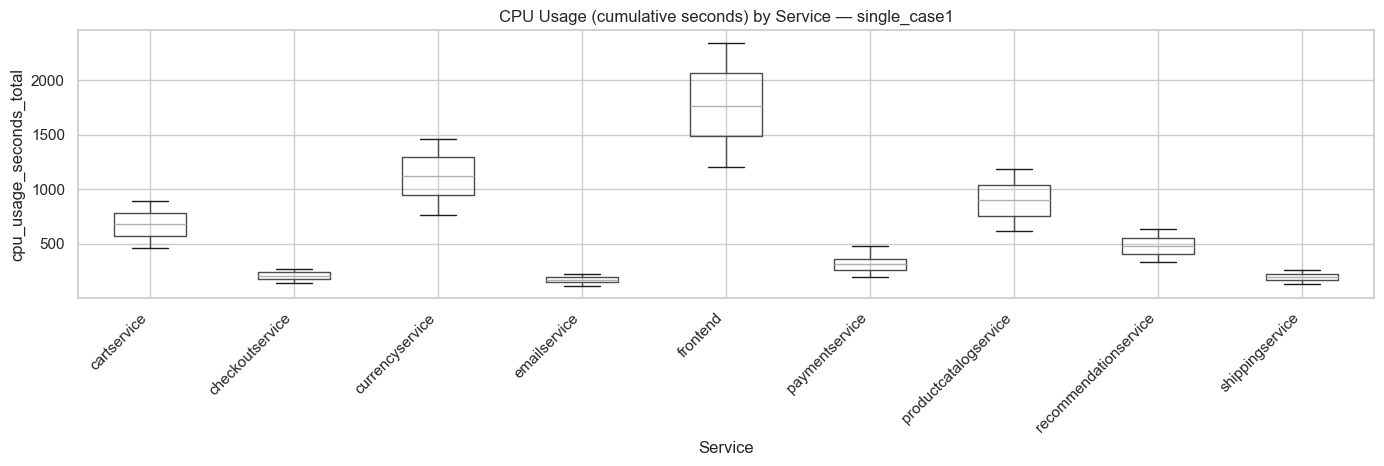

In [12]:
# ── CPU usage distribution per service (single_case1) ───────────────────────
df_ref = dfs['single_case1'].copy()
df_ref['service'] = df_ref['cmdb_id'].str.replace('observe.', '', regex=False).str.rsplit('-', n=1).str[0]

fig, ax = plt.subplots(figsize=(14, 5))
df_ref.boxplot(column='container_cpu_usage_seconds_total', by='service', ax=ax)
ax.set_title('CPU Usage (cumulative seconds) by Service — single_case1')
ax.set_xlabel('Service')
ax.set_ylabel('cpu_usage_seconds_total')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

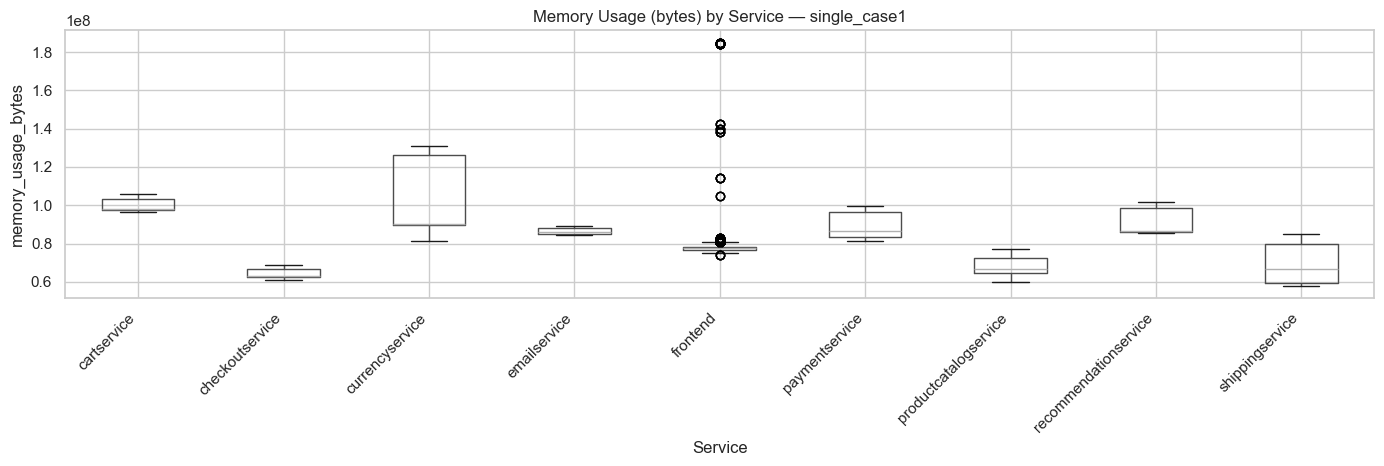

In [13]:
# ── Memory usage distribution per service ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
df_ref.boxplot(column='container_memory_usage_bytes', by='service', ax=ax)
ax.set_title('Memory Usage (bytes) by Service — single_case1')
ax.set_xlabel('Service')
ax.set_ylabel('memory_usage_bytes')
plt.suptitle('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

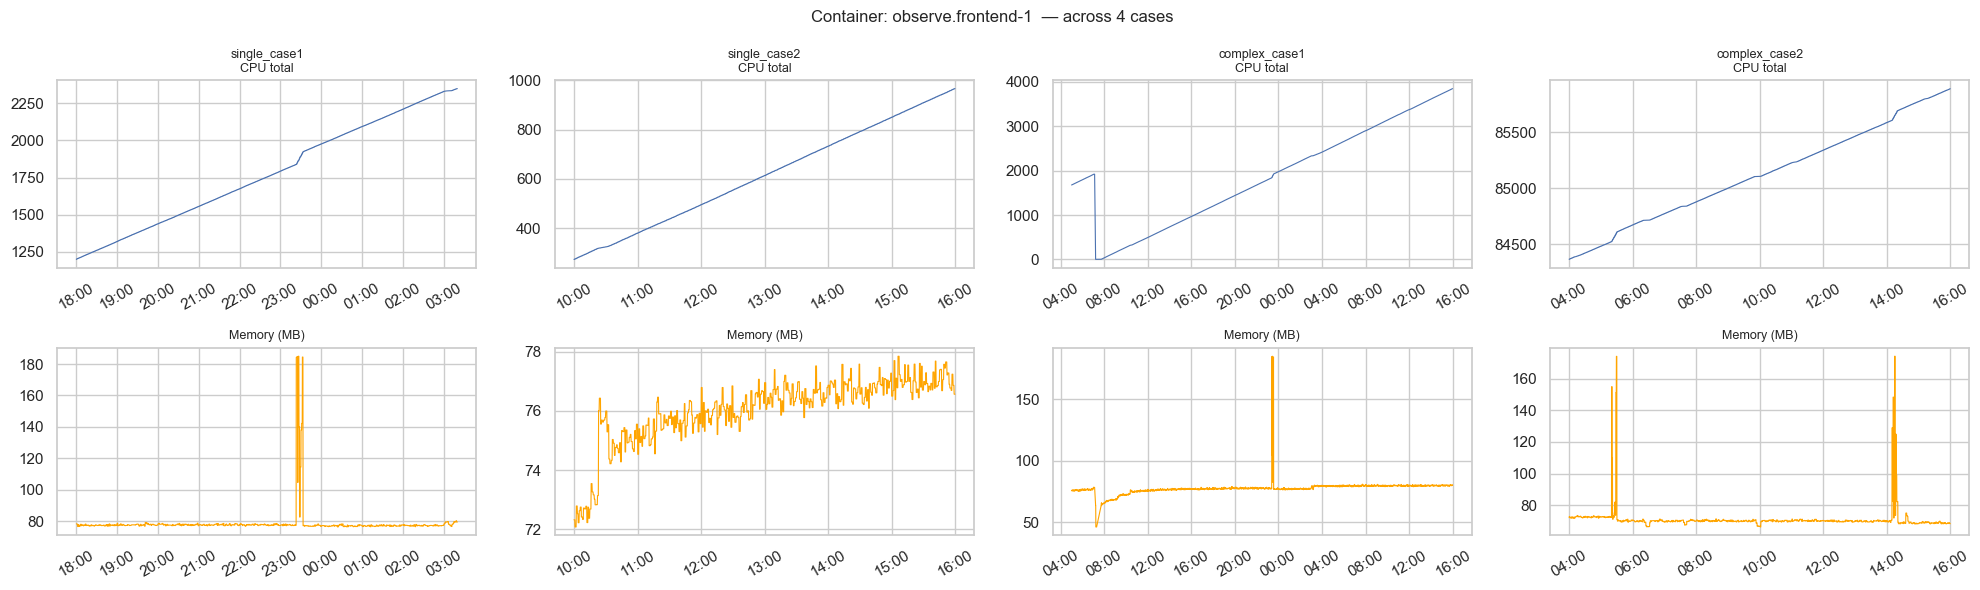

In [14]:
# ── Time series: CPU + Memory for one container across all 4 cases ──────────
TARGET = 'observe.frontend-1'   # appears in all 4 cases' groundtruth

fig, axes = plt.subplots(2, 4, figsize=(20, 6))

for col_idx, (case_name, df) in enumerate(dfs.items()):
    sub = df[df['cmdb_id'] == TARGET].sort_values('timestamp')

    axes[0, col_idx].plot(sub['datetime'], sub['container_cpu_usage_seconds_total'], lw=0.8)
    axes[0, col_idx].set_title(f'{case_name}\nCPU total', fontsize=9)
    axes[0, col_idx].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0, col_idx].tick_params(axis='x', rotation=30)

    axes[1, col_idx].plot(sub['datetime'], sub['container_memory_usage_bytes'] / 1e6, lw=0.8, color='orange')
    axes[1, col_idx].set_title(f'Memory (MB)', fontsize=9)
    axes[1, col_idx].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[1, col_idx].tick_params(axis='x', rotation=30)

fig.suptitle(f'Container: {TARGET}  — across 4 cases', fontsize=12)
plt.tight_layout()
plt.show()

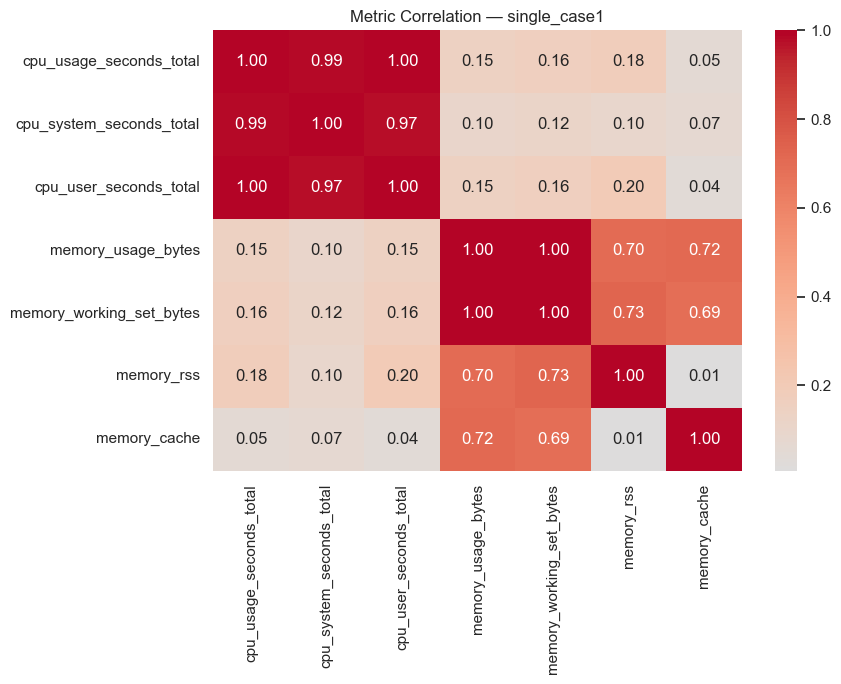

In [15]:
# ── Correlation heatmap of metrics (single_case1) ───────────────────────────
corr = dfs['single_case1'][METRIC_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[c.replace('container_', '') for c in METRIC_COLS],
            yticklabels=[c.replace('container_', '') for c in METRIC_COLS],
            ax=ax)
ax.set_title('Metric Correlation — single_case1')
plt.tight_layout()
plt.show()

In [16]:
# ── Groundtruth summary: how many fault events per case ─────────────────────
GT_PATHS = {
    'single_case1':  '../data/raw/Single Case-1/Case-1/groundtruth/groundtruth.json',
    'single_case2':  '../data/raw/Single Case-2/Case-2/groundtruth/groundtruth.json',
    'complex_case1': '../data/raw/Complex Case-1/Case-1/groundtruth/groundtruth.json',
    'complex_case2': '../data/raw/Complex Case-2/Case-2/groundtruth/groundtruth.json',
}

for name, path in GT_PATHS.items():
    with open(path) as f:
        gt = json.load(f)
    n = len(gt['timestamp'])
    types = pd.Series(gt['failure_type']).value_counts().to_dict()
    print(f'{name}: {n} fault events | types: {types}')

single_case1: 3 fault events | types: {'cpu': 1, 'memory': 1, 'loss': 1}
single_case2: 2 fault events | types: {'pod-failure': 2}
complex_case1: 12 fault events | types: {'pod-failure': 3, 'delay': 3, 'cpu': 2, 'memory': 2, 'loss': 2}
complex_case2: 23 fault events | types: {'loss': 9, 'memory': 6, 'cpu': 3, 'pod-failure': 3, 'delay': 2}


In [17]:
# ── Preview: which timestamps will be labeled anomaly (single_case1) ─────────
# Strip 'observe.' so cmdb_id matches groundtruth format
with open(GT_PATHS['single_case1']) as f:
    gt = json.load(f)

gt_df = pd.DataFrame(gt)
gt_df['start'] = gt_df['timestamp']
gt_df['end']   = gt_df['timestamp'] + gt_df['duration']
gt_df['datetime_start'] = pd.to_datetime(gt_df['start'], unit='s')
gt_df['datetime_end']   = pd.to_datetime(gt_df['end'],   unit='s')

print('Fault windows — single_case1:')
gt_df[['cmdb_id', 'failure_type', 'datetime_start', 'datetime_end', 'duration']].to_string(index=False)

Fault windows — single_case1:


'         cmdb_id failure_type      datetime_start        datetime_end  duration\npaymentservice-1          cpu 2024-06-24 19:20:00 2024-06-24 19:29:00       540\n      frontend-1       memory 2024-06-24 23:23:00 2024-06-24 23:33:00       600\n      frontend-1         loss 2024-06-25 03:00:00 2024-06-25 03:10:00       600'

In [18]:
# ── Estimate anomaly row % (quick preview before preprocessing) ───────────────
def count_anomaly_rows(df, gt):
    """Count rows that fall inside any fault window."""
    # Strip 'observe.' prefix
    df = df.copy()
    df['short_id'] = df['cmdb_id'].str.replace('observe.', '', regex=False)
    
    anomaly_mask = pd.Series(False, index=df.index)
    for ts, cid, dur in zip(gt['timestamp'], gt['cmdb_id'], gt['duration']):
        in_window   = (df['timestamp'] >= ts) & (df['timestamp'] < ts + dur)
        id_matches  = df['short_id'] == cid
        anomaly_mask |= (in_window & id_matches)
    
    return anomaly_mask.sum()

for name in CASES:
    with open(GT_PATHS[name]) as f:
        gt = json.load(f)
    df = dfs[name]
    n_anom = count_anomaly_rows(df, gt)
    pct    = n_anom / len(df) * 100
    print(f'{name}: {n_anom:,} anomaly rows / {len(df):,} total  ({pct:.1f}%)')

single_case1: 116 anomaly rows / 74,223 total  (0.2%)
single_case2: 56 anomaly rows / 45,738 total  (0.1%)
complex_case1: 1,242 anomaly rows / 318,445 total  (0.4%)
complex_case2: 812 anomaly rows / 94,932 total  (0.9%)
